# 🌍 Population Analysis Project

### This project explores global population trends using visualization techniques.

## Import Libraries

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset And Checking Data

In [3]:
df = pd.read_csv("API_SP.POP.TOTL_DS2_en_csv_v2_207128.csv", skiprows=4)
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN,NaN


## Clean Column Names

In [44]:
df.columns = df.columns.str.strip()

## Selecting a Safe Year

In [48]:
year = '2020'

In [49]:
df = df[['Country Name', year]]
df.head()

,Country Name,2020
0,Aruba,108587.0
1,Africa Eastern and Southern,694446100.0
2,Afghanistan,39068979.0
3,Africa Western and Central,474569351.0
4,Angola,33451132.0


## Handling missing values

In [50]:
df[year] = df[year].replace('..', None)

## Converting to Numeric Data

In [51]:
df[year] = pd.to_numeric(df[year], errors='coerce')

## Drop Empty rows

In [52]:
df = df.dropna()

In [53]:
df[year].describe()

count    2.650000e+02
mean     3.187768e+08
std      9.865558e+08
min      1.039900e+04
25%      1.790151e+06
50%      1.069786e+07
75%      6.097280e+07
max      7.854748e+09
Name: 2020, dtype: float64

## Setting Visualization Style and Context

In [54]:
sns.set_style("whitegrid")
sns.set_context("talk")

In [55]:
top10 = df.sort_values(by=year, ascending=False).head(10)

## Visualization 1: Histogram

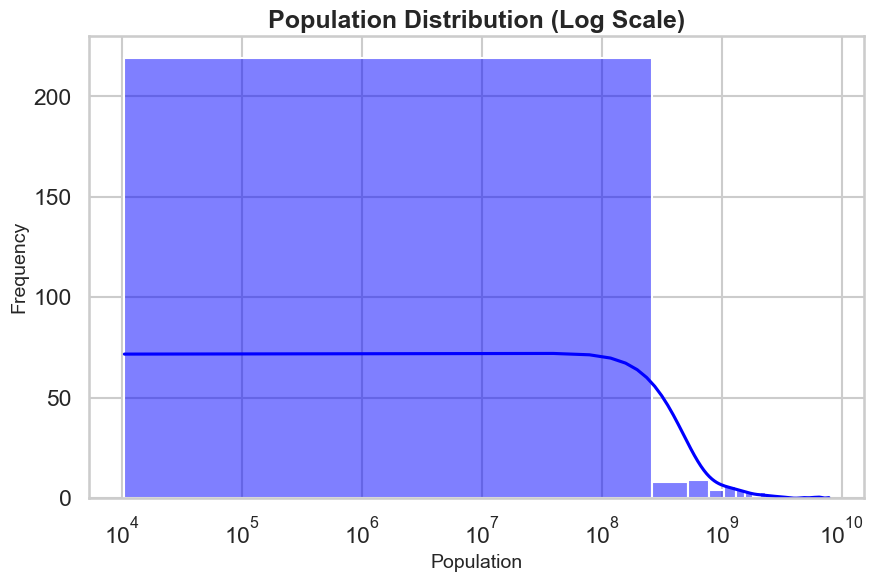

In [56]:
plt.figure(figsize=(10,6))

sns.histplot(df[year], bins=30, kde=True, color='blue')

plt.xscale('log')
plt.title("Population Distribution (Log Scale)", fontsize=18, fontweight='bold')
plt.xlabel("Population", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

## Visualization 2: Bar Chart

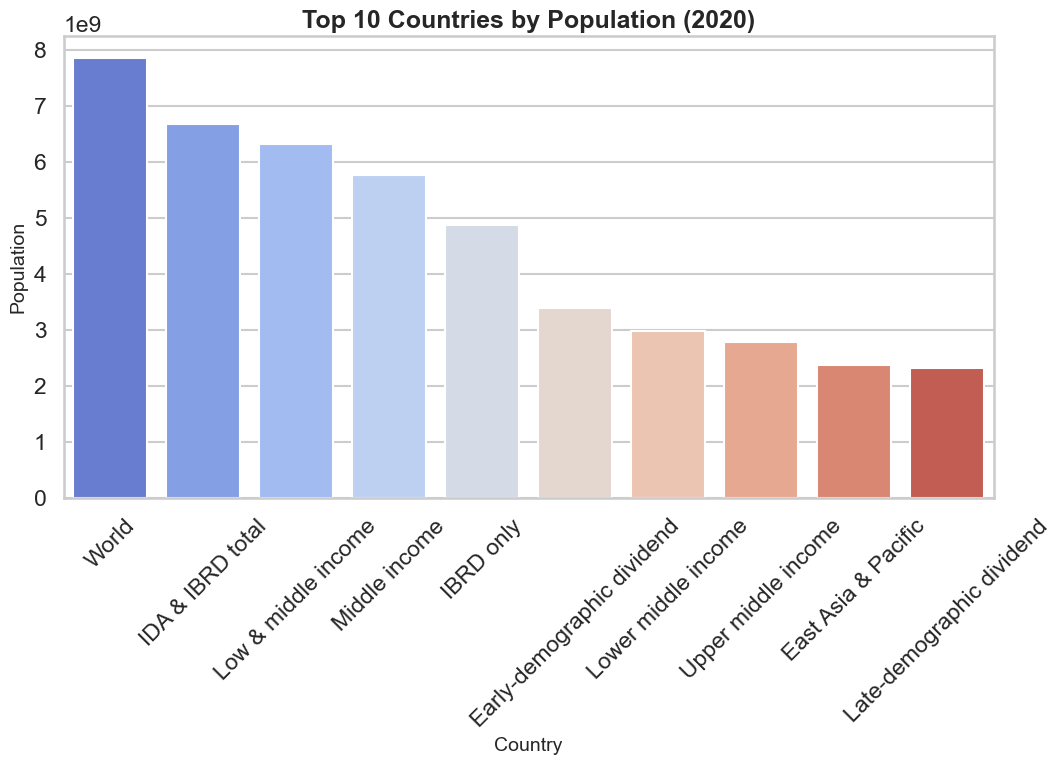

In [57]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=top10['Country Name'], 
    y=top10[year], 
    hue=top10['Country Name'], 
    palette='coolwarm',
    legend=False
)
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Population (2020)", fontsize=18, fontweight='bold')
plt.xlabel("Country", fontsize=14)
plt.ylabel("Population", fontsize=14)
plt.show()

## Conclusion

#### The histogram shows that population distribution is highly skewed.
#### Most countries have small populations.
#### A few countries have extremely large populations.
#### The bar chart shows the top 10 most populated countries.
#### Countries like India and China dominate the global population.